#### 1. Start Spark

In [20]:
import pyspark
import pyspark.sql.functions as F
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# Start spark
spark = (
    pyspark.sql.SparkSession.builder
    .appName("eda")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

#### 2. Load all datasets

In [4]:
# Dictionary of path
paths = {
    "clickstream": "data/feature_clickstream.csv",
    "attributes": "data/features_attributes.csv",
    "financials": "data/features_financials.csv",
    "lms": "data/lms_loan_daily.csv"
}

dfs = {}

for name, file_path in paths.items():
    df = spark.read.csv(file_path, header=True, inferSchema=True)
    dfs[name] = df
    
    print(f"\n===== {name} =====")
    print("Rows:", df.count())
    print("Columns:", len(df.columns))
    df.printSchema()
    display(df.toPandas())


===== clickstream =====
Rows: 215376
Columns: 22
root
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer (nullable = true)
 |-- fe_5: integer (nullable = true)
 |-- fe_6: integer (nullable = true)
 |-- fe_7: integer (nullable = true)
 |-- fe_8: integer (nullable = true)
 |-- fe_9: integer (nullable = true)
 |-- fe_10: integer (nullable = true)
 |-- fe_11: integer (nullable = true)
 |-- fe_12: integer (nullable = true)
 |-- fe_13: integer (nullable = true)
 |-- fe_14: integer (nullable = true)
 |-- fe_15: integer (nullable = true)
 |-- fe_16: integer (nullable = true)
 |-- fe_17: integer (nullable = true)
 |-- fe_18: integer (nullable = true)
 |-- fe_19: integer (nullable = true)
 |-- fe_20: integer (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,63,118,80,121,55,193,111,112,-101,83,...,-16,-81,-126,114,35,85,-73,76,CUS_0x1037,2023-01-01
1,-108,182,123,4,-56,27,25,-6,284,222,...,-14,-96,200,35,130,94,111,75,CUS_0x1069,2023-01-01
2,-13,8,87,166,214,-98,215,152,129,139,...,26,86,171,125,-130,354,17,302,CUS_0x114a,2023-01-01
3,-85,45,200,89,128,54,76,51,61,139,...,172,96,174,163,37,207,180,118,CUS_0x1184,2023-01-01
4,55,120,226,-86,253,97,107,68,103,126,...,76,43,183,159,-26,104,118,184,CUS_0x1297,2023-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215371,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
215372,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
215373,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
215374,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01



===== attributes =====
Rows: 12500
Columns: 6
root
 |-- Customer_ID: string (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: string (nullable = true)
 |-- SSN: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01
...,...,...,...,...,...,...
12495,CUS_0xff3,Somervilled,55,#F%$D@*&8,Scientist,2024-06-01
12496,CUS_0xff4,Poornimaf,37,655-05-7666,Entrepreneur,2024-12-01
12497,CUS_0xff6,Shieldsb,19,541-92-8371,Doctor,2024-10-01
12498,CUS_0xffc,Brads,18,226-86-7294,Musician,2024-01-01



===== financials =====
Rows: 12500
Columns: 22
root
 |-- Customer_ID: string (nullable = true)
 |-- Annual_Income: string (nullable = true)
 |-- Monthly_Inhand_Salary: double (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: integer (nullable = true)
 |-- Num_of_Loan: string (nullable = true)
 |-- Type_of_Loan: string (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: string (nullable = true)
 |-- Changed_Credit_Limit: string (nullable = true)
 |-- Num_Credit_Inquiries: double (nullable = true)
 |-- Credit_Mix: string (nullable = true)
 |-- Outstanding_Debt: string (nullable = true)
 |-- Credit_Utilization_Ratio: double (nullable = true)
 |-- Credit_History_Age: string (nullable = true)
 |-- Payment_of_Min_Amount: string (nullable = true)
 |-- Total_EMI_per_month: double (nullable = true)
 |-- Amount_invested_monthly: string (nullable = true)
 |-- Payme

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x1000,30625.94,2706.161667,6,5,27,2,"Credit-Builder Loan, and Home Equity Loan",57,26,...,Bad,1562.91,30.077191,10 Years and 9 Months,Yes,42.941090,77.31427572208112,High_spent_Medium_value_payments,400.36080052211616,2023-05-01
1,CUS_0x1009,52312.68_,4250.390000,6,5,17,4,"Not Specified, Home Equity Loan, Credit-Builde...",5,18,...,_,202.68,40.286997,31 Years and 0 Months,Yes,108.366467,58.66019164829086,High_spent_Medium_value_payments,508.01234122645366,2025-01-01
2,CUS_0x100b,113781.38999999998,9549.782500,1,4,1,0,None,14,8,...,Good,1030.2,28.592943,15 Years and 10 Months,No,0.000000,617.0792665202719,High_spent_Small_value_payments,597.8989834797281,2024-03-01
3,CUS_0x1011,58918.47,5208.872500,3,3,17,3,"Student Loan, Credit-Builder Loan, and Debt Co...",27,13,...,Standard,473.14,27.829959,15 Years and 10 Months,Yes,123.434939,383.35084463651407,Low_spent_Medium_value_payments,294.1014665671429,2023-11-01
4,CUS_0x1013,98620.98,7962.415000,3,3,6,3,"Student Loan, Debt Consolidation Loan, and Per...",12,9,...,Good,1233.51,26.524864,17 Years and 10 Months,No,228.018084,332.3337079767732,High_spent_Medium_value_payments,485.8897083704929,2023-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12495,CUS_0xff3,17032.785,1176.398750,0,6,2,3,"Personal Loan, Mortgage Loan, and Auto Loan",13,7_,...,Good,1229.08,26.915577,17 Years and 3 Months,No,33.299764,81.19585741743609,Low_spent_Small_value_payments,293.14425404017936,2024-06-01
12496,CUS_0xff4,25546.26,2415.855000,8,7,14,5_,"Not Specified, Student Loan, Student Loan, Cre...",15,13_,...,Standard,758.44,39.333488,18 Years and 9 Months,Yes,101.328637,189.81586133347676,Low_spent_Medium_value_payments,230.44100130267208,2024-12-01
12497,CUS_0xff6,117639.92,9727.326667,5,6,1,2,"Home Equity Loan, and Auto Loan",-3,7,...,Good,338.3,32.871853,24 Years and 11 Months,No,126.638453,534.0885271982645,Low_spent_Medium_value_payments,592.0056861539196,2024-10-01
12498,CUS_0xffc,60877.17,5218.097500,6,8,27,8,"Credit-Builder Loan, Payday Loan, Not Specifie...",46,14,...,_,1300.13,29.026498,13 Years and 1 Months,Yes,272.809169,46.4256138380274,High_spent_Large_value_payments,442.5749666782518,2024-01-01



===== lms =====
Rows: 137500
Columns: 11
root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- loan_start_date: date (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- installment_num: integer (nullable = true)
 |-- loan_amt: integer (nullable = true)
 |-- due_amt: double (nullable = true)
 |-- paid_amt: double (nullable = true)
 |-- overdue_amt: double (nullable = true)
 |-- balance: double (nullable = true)
 |-- snapshot_date: date (nullable = true)



,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,0,10000,0.0,0.0,0.0,10000.0,2023-05-01
1,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,1,10000,1000.0,1000.0,0.0,9000.0,2023-06-01
2,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2023-07-01
3,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,3,10000,1000.0,0.0,1000.0,8000.0,2023-08-01
4,CUS_0x1000_2023_05_01,CUS_0x1000,2023-05-01,10,4,10000,1000.0,2000.0,0.0,6000.0,2023-09-01
...,...,...,...,...,...,...,...,...,...,...,...
137495,CUS_0xffd_2024_03_01,CUS_0xffd,2024-03-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-09-01
137496,CUS_0xffd_2024_03_01,CUS_0xffd,2024-03-01,10,7,10000,1000.0,1000.0,0.0,3000.0,2024-10-01
137497,CUS_0xffd_2024_03_01,CUS_0xffd,2024-03-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-11-01
137498,CUS_0xffd_2024_03_01,CUS_0xffd,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01


#### 3. Check column names

In [5]:
for name, df in dfs.items():
    print(f"\n{name}")
    print(df.columns)


clickstream
['fe_1', 'fe_2', 'fe_3', 'fe_4', 'fe_5', 'fe_6', 'fe_7', 'fe_8', 'fe_9', 'fe_10', 'fe_11', 'fe_12', 'fe_13', 'fe_14', 'fe_15', 'fe_16', 'fe_17', 'fe_18', 'fe_19', 'fe_20', 'Customer_ID', 'snapshot_date']

attributes
['Customer_ID', 'Name', 'Age', 'SSN', 'Occupation', 'snapshot_date']

financials
['Customer_ID', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'snapshot_date']

lms
['loan_id', 'Customer_ID', 'loan_start_date', 'tenure', 'installment_num', 'loan_amt', 'due_amt', 'paid_amt', 'overdue_amt', 'balance', 'snapshot_date']


#### 4. Check missing values

In [6]:
for name, df in dfs.items():
    print(f"\n===== Missing values: {name} =====")
    
    missing_summary = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ])
    
    display(missing_summary.toPandas())


===== Missing values: clickstream =====


,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



===== Missing values: attributes =====


,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,0,0,0,0,0,0



===== Missing values: financials =====


,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,0,0,0,0,0,0,0,1426,0,0,...,0,0,0,0,0,0,0,0,0,0



===== Missing values: lms =====


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,0,0,0,0,0,0,0,0,0,0,0


#### 5. Check duplicates

In [7]:
for name, df in dfs.items():
    total_rows = df.count()
    distinct_rows = df.dropDuplicates().count()
    
    print(f"{name}:")
    print("Total rows:", total_rows)
    print("Distinct rows:", distinct_rows)
    print("Duplicate rows:", total_rows - distinct_rows)

clickstream:
Total rows: 215376
Distinct rows: 215376
Duplicate rows: 0
attributes:
Total rows: 12500
Distinct rows: 12500
Duplicate rows: 0
financials:
Total rows: 12500
Distinct rows: 12500
Duplicate rows: 0
lms:
Total rows: 137500
Distinct rows: 137500
Duplicate rows: 0


#### 6. Check snapshot dates

In [8]:
for name, df in dfs.items():
    print(f"\n===== Snapshot dates: {name} =====")
    
    if "snapshot_date" in df.columns:
        df.groupBy("snapshot_date").count().orderBy("snapshot_date").show(100, truncate=False)
    else:
        print("No snapshot_date column")


===== Snapshot dates: clickstream =====
+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|2023-01-01   |8974 |
|2023-02-01   |8974 |
|2023-03-01   |8974 |
|2023-04-01   |8974 |
|2023-05-01   |8974 |
|2023-06-01   |8974 |
|2023-07-01   |8974 |
|2023-08-01   |8974 |
|2023-09-01   |8974 |
|2023-10-01   |8974 |
|2023-11-01   |8974 |
|2023-12-01   |8974 |
|2024-01-01   |8974 |
|2024-02-01   |8974 |
|2024-03-01   |8974 |
|2024-04-01   |8974 |
|2024-05-01   |8974 |
|2024-06-01   |8974 |
|2024-07-01   |8974 |
|2024-08-01   |8974 |
|2024-09-01   |8974 |
|2024-10-01   |8974 |
|2024-11-01   |8974 |
|2024-12-01   |8974 |
+-------------+-----+


===== Snapshot dates: attributes =====
+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|2023-01-01   |530  |
|2023-02-01   |501  |
|2023-03-01   |506  |
|2023-04-01   |510  |
|2023-05-01   |521  |
|2023-06-01   |517  |
|2023-07-01   |471  |
|2023-08-01   |481  |
|2023-09-01   |454  |
|2023-10-01   |487  |
|2023-11-01   |4

In [9]:
for name, df in dfs.items():
    print(f"\n===== Numeric summary: {name} =====")
    
    summary_pdf = df.describe().toPandas()
    display(summary_pdf)


===== Numeric summary: clickstream =====


,summary,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,...,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID
0,count,215376,215376,215376,215376,215376,215376,215376,215376,215376,...,215376,215376,215376,215376,215376,215376,215376,215376,215376,215376
1,mean,101.41479552039225,103.09619456206819,104.33370941980536,105.64850308298047,106.99667558130896,103.23592229403462,107.0703374563554,110.71872446326425,114.40635446846446,...,99.82368044721788,100.420803617859,100.02580138919842,99.60038258673204,99.86083407622019,100.12942481984993,100.12513929128593,100.341161503603,100.04625863605973,None
2,stddev,99.83359392844184,99.93000203749298,100.59986549187705,100.32606477046183,100.69360665858557,100.27038751891193,100.32326515826574,100.24369781781921,100.18613852691671,...,100.59117511972615,100.88182648131858,101.0703707917751,101.14590617776975,100.75187641058751,101.29842811875086,102.23158668008934,102.66680374052808,103.58935787523686,None
3,min,-378,-356,-399,-307,-343,-321,-368,-361,-328,...,-344,-355,-394,-351,-342,-329,-344,-401,-354,CUS_0x1000
4,max,541,560,583,562,570,565,537,573,577,...,550,530,583,597,554,516,551,560,547,CUS_0xffd



===== Numeric summary: attributes =====


,summary,Customer_ID,Name,Age,SSN,Occupation
0,count,12500,12500,12500,12500,12500
1,mean,None,None,104.40925566888646,None,None
2,stddev,None,None,659.4794049008866,None,None
3,min,CUS_0x1000,Mattr,-500,#F%$D@*&8,Accountant
4,max,CUS_0xffd,yv,925,999-99-3421,_______



===== Numeric summary: financials =====


,summary,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,count,12500,12500,12500,12500,12500,12500,12500,11074,12500,...,12500,12500,12500,12500,12500,12500,12500,12500,12500,12500
1,mean,None,165302.13805472082,4188.5923027131585,16.93992,23.17272,73.21336,2.8950071566894,None,21.06088,...,26.69528,None,1427.0757916026269,32.34926457800977,None,None,1488.3942909941488,194.61439930668595,None,403.9209152933519
2,stddev,None,1318317.705695486,3180.1476109204173,114.35081529709485,132.00586642912222,468.68222710052765,65.49885397088406,None,14.863091419503656,...,184.19382871053074,None,1155.35859669298,5.156815304530768,None,None,8561.449910123256,200.6255800057787,None,213.92619077547045
3,min,CUS_0x1000,10003.495_,303.6454166666666,-1,0,1,-100,Auto Loan,-5,...,0.0,Bad,0.23,20.10076996070649,0 Years and 10 Months,NM,0.0,0.0,!@9#%8,0.3825579787828133
4,max,CUS_0xffd,99995.22,15204.633333333331,1756,1499,5789,9_,"Student Loan, and Student Loan",67,...,2554.0,_,999.48,48.19982397892475,9 Years and 9 Months,Yes,81971.0,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__



===== Numeric summary: lms =====


,summary,loan_id,Customer_ID,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance
0,count,137500,137500,137500,137500,137500,137500,137500,137500,137500
1,mean,None,None,10.0,5.0,10000.0,909.0909090909091,711.810909090909,871.9054545454545,5871.905454545455
2,stddev,None,None,0.0,3.162289159422599,0.0,287.48083267477995,485.72685937838196,2002.6725443189466,3070.777574545779
3,min,CUS_0x1000_2023_05_01,CUS_0x1000,10,0,10000,0.0,0.0,0.0,0.0
4,max,CUS_0xffd_2024_03_01,CUS_0xffd,10,10,10000,1000.0,4000.0,10000.0,10000.0


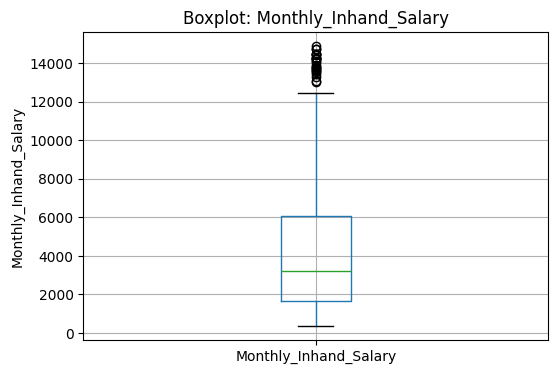

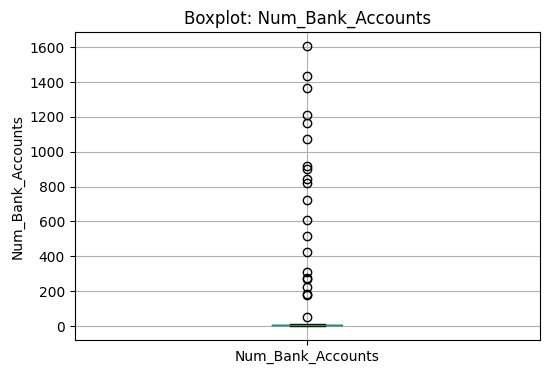

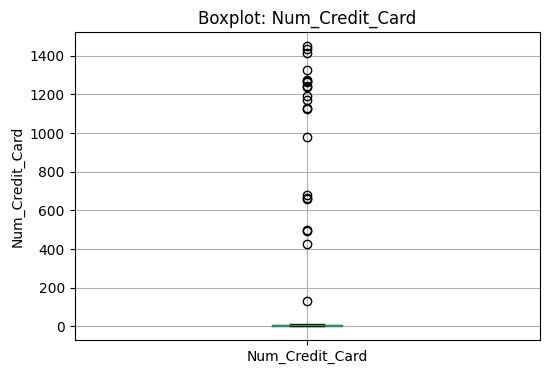

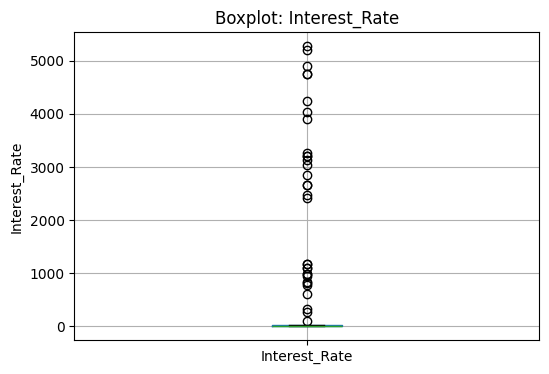

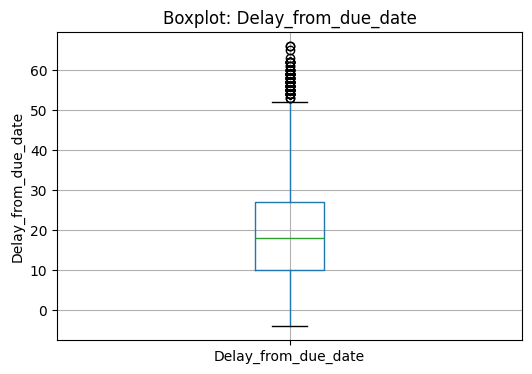

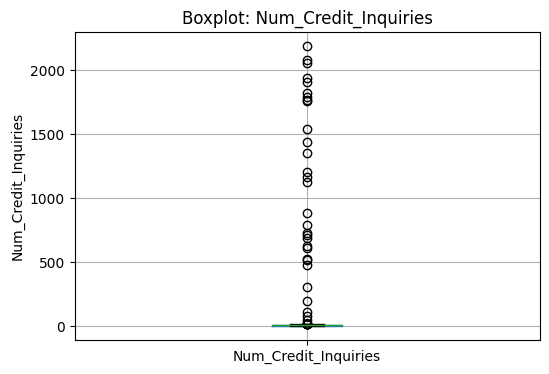

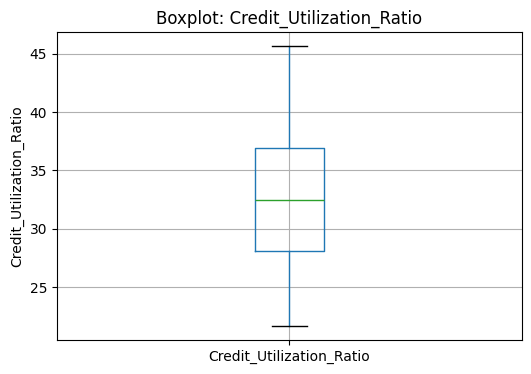

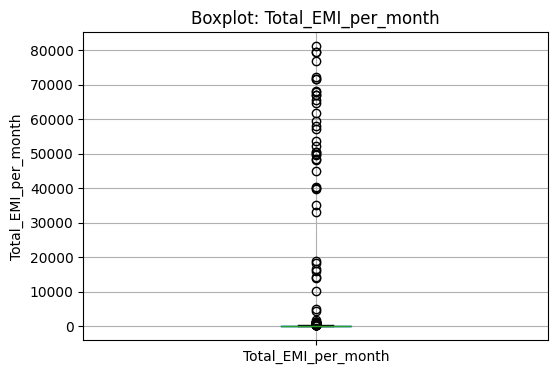

In [23]:

df = dfs["financials"]  # change dataset here

numeric_cols = [
    field.name
    for field in df.schema.fields
    if field.dataType.simpleString() in ["int", "bigint", "double", "float"]
]

pdf = df.select(numeric_cols).sample(False, 0.1, seed=42).toPandas()

for col_name in numeric_cols:
    plt.figure(figsize=(6, 4))
    pdf.boxplot(column=col_name)
    plt.title(f"Boxplot: {col_name}")
    plt.ylabel(col_name)
    plt.show()